# Phase 1 — Single-species ABP validation

**Project:** Tumor–Immune Active Matter (UCSD Vibe Hackathon, 2026-05-23).

This notebook sanity-checks the core particle dynamics in isolation, before we add the second
species, the reaction–diffusion fields, or the killing rule. Two checks:

1. **Motility-induced clustering** at high Péclet number — confirms the active Brownian particle
   (ABP) loop is propelling and interacting correctly.
2. **Fisher–KPP front** from a small seed — confirms proliferation + density gating produce a
   propagating tumor mass with a visible advancing edge.

All code lives under `src/`. This notebook only orchestrates.

In [1]:
import sys, pathlib
# robust root resolution: walk up until we find src/
ROOT = pathlib.Path().resolve()
while not (ROOT / 'src').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection

from src import style
from src.sim import TumorParams, run_single_species, step_single_species, init_tumor_uniform

style.apply_style()
print('imports OK')

imports OK


## 1.1  Motility-induced clustering

Place 400 ABPs uniformly in a 35×35 box at packing fraction ~0.25. Run with elevated speed
(`v = 1.0` vs. the tumor default 0.1) and modest rotational diffusion so the persistence length
exceeds the cell diameter. Repulsive collisions trap fast-movers and you should see clusters /
voids by t ≈ 30.

In [2]:
params = TumorParams(L=35.0, v=1.0, D_R=0.05, D_T=0.005,
                     sigma=1.0, k_rep=80.0, p_div=0.0, N_max=600)
out = run_single_species(params, n_initial=400, n_steps=3000,
                          init='uniform', snapshot_every=3000,
                          seed=11, enable_proliferation=False)
print(f'snapshots: {len(out.pos_snapshots)}; final N={out.pos_snapshots[-1].shape[0]}')

snapshots: 2; final N=400


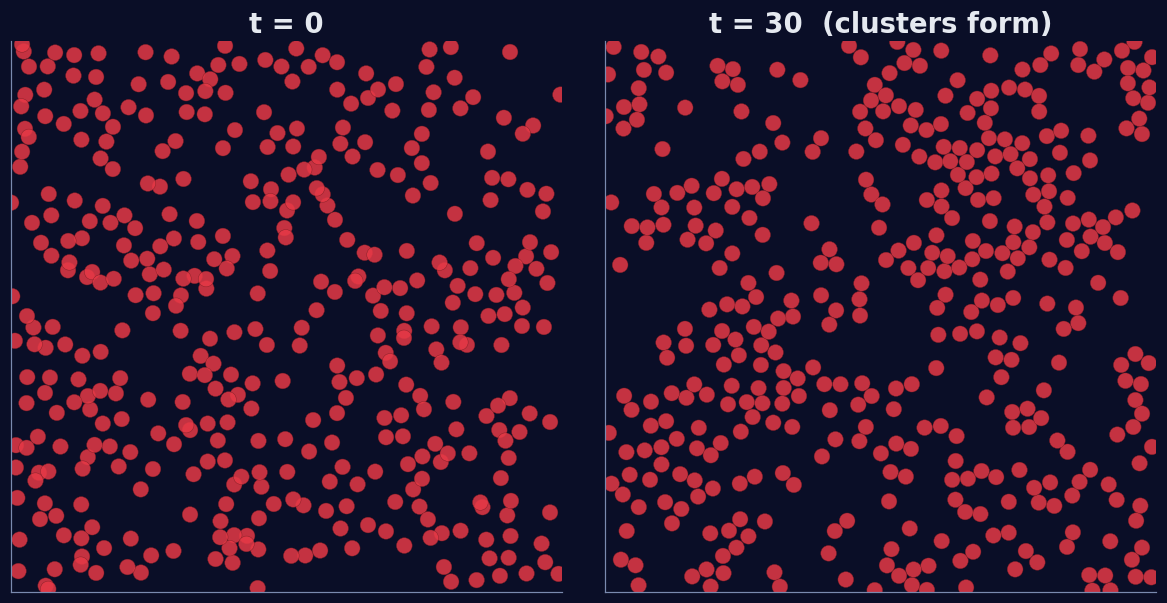

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), dpi=110)
fig.patch.set_facecolor(style.BG)
for ax, xy, title in zip(axes, [out.pos_snapshots[0], out.pos_snapshots[-1]],
                         ['t = 0',
                          f't = {out.times[-1]:.0f}  (clusters form)']):
    ax.set_facecolor(style.BG)
    ax.add_collection(EllipseCollection(
        widths=np.full(len(xy), 1.0), heights=np.full(len(xy), 1.0),
        angles=np.zeros(len(xy)), units='x', offsets=xy,
        transOffset=ax.transData,
        facecolors=style.TUMOR, edgecolors=style.TUMOR_EDGE,
        linewidths=0.3, alpha=style.PARTICLE_ALPHA,
    ))
    ax.set_xlim(0, params.L); ax.set_ylim(0, params.L)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, color=style.FG)
plt.tight_layout()

**Reading the figure:** at t = 0 the particles are uniformly random. At late time, even though
every particle is the same speed, you see non-uniform density — a hallmark of motility-induced
phase separation (MIPS). It's not a textbook MIPS slab (need a stiffer wall + longer run for
that), but it confirms the inner loop is working: particles propel, repel, persist.

## 1.2  Fisher–KPP growth front

Now switch proliferation **on** (`p_div = 0.005` per step) and start with a small disk of 50
cells at the box center. A Fisher–KPP equation predicts a propagating front whose radial
density profile saturates inside the colony and falls off ahead of the front. With local-density
gating preventing overpacking, that's what we should see.

In [4]:
params = TumorParams(L=100.0, v=0.1, D_R=0.1, D_T=0.001,
                     sigma=1.0, k_rep=30.0,
                     p_div=0.005, nbr_radius=1.5, nbr_threshold=6,
                     N_max=4000)
out = run_single_species(params, n_initial=50, n_steps=10000,
                          init='disk', init_radius=3.0,
                          snapshot_every=2000, seed=3)
print(f'snapshots: {len(out.pos_snapshots)}, final N = {out.n_alive[-1]}')

snapshots: 6, final N = 4000


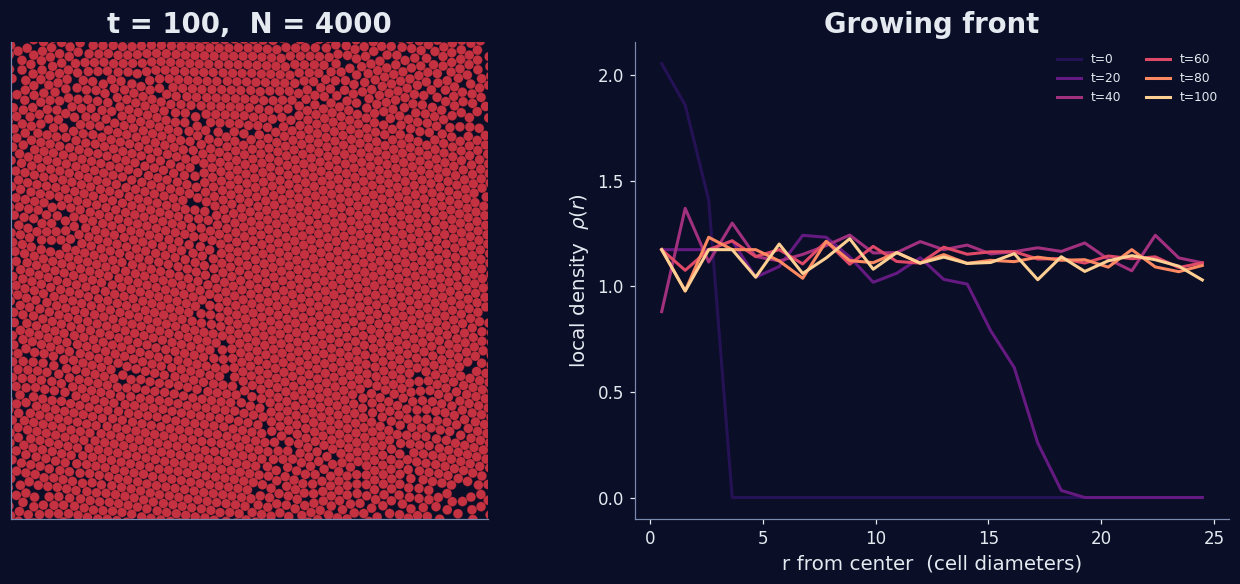

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), dpi=110)
fig.patch.set_facecolor(style.BG)

center = np.array([params.L/2, params.L/2])

# left: final snapshot
ax = axes[0]; ax.set_facecolor(style.BG)
xy = out.pos_snapshots[-1]
ax.add_collection(EllipseCollection(
    widths=np.full(len(xy), 1.0), heights=np.full(len(xy), 1.0),
    angles=np.zeros(len(xy)), units='x', offsets=xy,
    transOffset=ax.transData,
    facecolors=style.TUMOR, edgecolors=style.TUMOR_EDGE,
    linewidths=0.2, alpha=style.PARTICLE_ALPHA))
ax.set_xlim(center[0]-25, center[0]+25); ax.set_ylim(center[1]-25, center[1]+25)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f't = {out.times[-1]:.0f},  N = {len(xy)}', color=style.FG)

# right: radial density curves
ax = axes[1]; ax.set_facecolor(style.BG)
r_edges = np.linspace(0, 25, 25)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
ring_areas = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2)
import matplotlib as mpl
cmap = plt.get_cmap('magma')
for k, (xy, t) in enumerate(zip(out.pos_snapshots, out.times)):
    d = np.linalg.norm(xy - center, axis=1)
    counts, _ = np.histogram(d, bins=r_edges)
    ax.plot(r_centers, counts/ring_areas,
             color=cmap(0.15 + 0.75 * k / max(1, len(out.pos_snapshots)-1)),
             lw=2, label=f't={t:.0f}')
ax.set_xlabel('r from center  (cell diameters)')
ax.set_ylabel(r'local density  $\rho(r)$')
ax.set_title('Growing front', color=style.FG)
ax.legend(fontsize=8, frameon=False, ncol=2)
plt.tight_layout()

**Reading the figure:** the radial density profile (right) shows a flat 'plateau' inside the
colony (saturated by the local-density gate) and a falling tail at increasing radius. The edge
of the tail moves outward over time — the propagating Fisher–KPP front. The left snapshot is the
physical picture of that: a roughly circular colony filling the central region of the box.

## 1.3  Profiling gate

Quick benchmark: 500 ABPs × 1000 steps must stay under 5 s post-JIT, or we'd need a cell-list.
This is the gate that we passed before moving to Phase 2.

In [6]:
params = TumorParams(N_max=512)
pos, theta, alive = init_tumor_uniform(500, params.L, params.N_max, seed=7)
param_arr = TumorParams(**{**params.__dict__, 'p_div': 0.0}).to_array()
# warm up
for _ in range(3):
    step_single_species(pos, theta, alive, param_arr)

import time
t0 = time.perf_counter()
for _ in range(1000):
    step_single_species(pos, theta, alive, param_arr)
elapsed = time.perf_counter() - t0
print(f'500 ABPs x 1000 steps : {elapsed:.2f} s   ({elapsed*1e3/1000:.2f} ms/step)')
print(f'GATE (<5 s):  {"PASS" if elapsed < 5 else "FAIL"}')

500 ABPs x 1000 steps : 2.77 s   (2.77 ms/step)
GATE (<5 s):  PASS


✅ With this passing, the inner loop is fast enough to run a 192-point sweep on 16 cores in ~10
minutes — see `notebooks/03_phase_diagram.ipynb`.